# Lógica difusa aplicada a un servicio de soporte

**Nivel:** principiante  
**Entorno:** Google Colab  
**Tema:** priorización inteligente de tickets

## Contexto del caso

Un centro de atención recibe tickets de clientes. El equipo necesita decidir qué solicitudes atender primero. Para hacerlo considera dos factores:

- **Urgencia:** qué tan rápido necesita solución el cliente.
- **Impacto:** cuántas personas o procesos resultan afectados.

En la vida real, no siempre es correcto usar límites rígidos. Un ticket con urgencia 6 no es completamente diferente de uno con urgencia 5.9. La lógica difusa permite expresar valores intermedios como ‘poco urgente’, ‘moderadamente urgente’ o ‘muy urgente’.

El objetivo será calcular una prioridad de atención entre 0 y 100 y clasificarla como baja, media, alta o crítica.

## Explicación muy sencilla de la idea

Imagina que un supervisor recibe un ticket y dice: ‘parece bastante urgente y afecta a muchas personas’. Esa forma de hablar no usa límites perfectos; usa grados. La lógica difusa convierte esas palabras humanas en números para que una computadora pueda trabajar con ellas.

La computadora no dirá únicamente `urgente = sí` o `urgente = no`. Puede decir:

```text
urgencia baja  = 0.10
urgencia media = 0.40
urgencia alta  = 0.60
```

Esto significa que el ticket se parece un poco a un caso medio y más a un caso alto. Después, las reglas combinan esa información para producir una prioridad gradual.

## ¿Por qué aplica la lógica difusa en servicios?

Muchas decisiones de servicio dependen de conceptos subjetivos:

- ¿El cliente está bastante molesto o muy molesto?
- ¿El problema afecta a pocas personas o a toda la operación?
- ¿La espera es tolerable o ya es demasiado larga?

La lógica tradicional obliga a elegir entre verdadero y falso. La lógica difusa permite que una situación pertenezca parcialmente a varias categorías al mismo tiempo. Por ejemplo, una urgencia de 6 puede ser 40% ‘media’ y 60% ‘alta’.

## Objetivos de aprendizaje

1. Crear funciones de pertenencia difusa.
2. Convertir valores numéricos en conceptos como bajo, medio y alto.
3. Aplicar reglas difusas con las palabras `Y` y `ENTONCES`.
4. Convertir varias reglas en una prioridad final.
5. Interpretar el resultado en lenguaje sencillo.

## 1. Preparar el entorno

Usaremos únicamente `numpy` para los cálculos y `matplotlib` para las gráficas. No se necesita instalar un paquete especial de lógica difusa; construiremos una versión educativa para observar cada paso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
print("Entorno listo.")

Entorno listo.


## 2. Crear funciones de pertenencia

Una función de pertenencia indica cuánto pertenece un valor a una categoría. El resultado siempre está entre 0 y 1:

- `0` significa que no pertenece.
- `1` significa que pertenece completamente.
- Un valor como `0.6` significa pertenencia parcial.

Usaremos triángulos sencillos para representar los conceptos bajo, medio y alto.

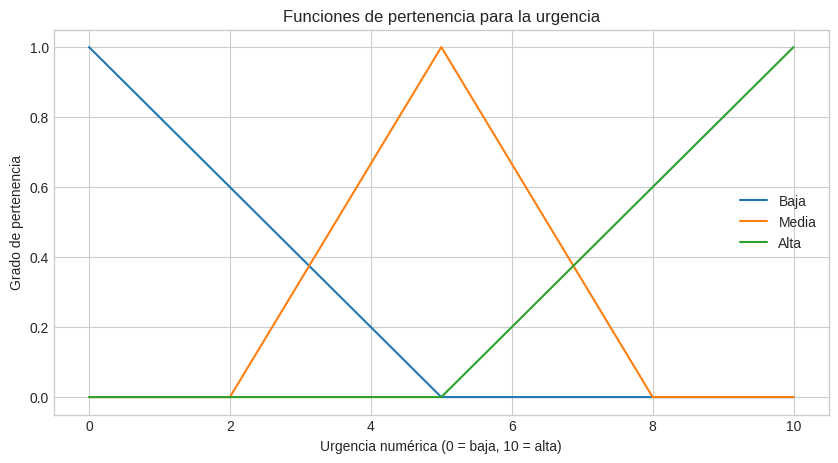

In [2]:
def triangular(x, izquierda, centro, derecha):
    """Calcula pertenencia a una categoría triangular o de borde."""
    x = np.asarray(x, dtype=float)

    # Categoría de borde izquierdo: pertenece por completo en 0.
    if izquierda == centro:
        return np.where(
            x <= centro, 1.0,
            np.where(x < derecha, (derecha - x) / (derecha - centro), 0.0)
        )

    # Categoría de borde derecho: pertenece por completo en 10.
    if centro == derecha:
        return np.where(
            x >= centro, 1.0,
            np.where(x > izquierda, (x - izquierda) / (centro - izquierda), 0.0)
        )

    subida = (x - izquierda) / (centro - izquierda)
    bajada = (derecha - x) / (derecha - centro)
    return np.maximum(0, np.minimum(subida, bajada))

valores = np.linspace(0, 10, 201)

urgencia_baja = triangular(valores, 0, 0, 5)
urgencia_media = triangular(valores, 2, 5, 8)
urgencia_alta = triangular(valores, 5, 10, 10)

plt.figure(figsize=(10, 5))
plt.plot(valores, urgencia_baja, label="Baja")
plt.plot(valores, urgencia_media, label="Media")
plt.plot(valores, urgencia_alta, label="Alta")
plt.title("Funciones de pertenencia para la urgencia")
plt.xlabel("Urgencia numérica (0 = baja, 10 = alta)")
plt.ylabel("Grado de pertenencia")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

### ¿Por qué también debemos observar el impacto?

La decisión no depende solo de la urgencia. Un problema puede no ser muy urgente, pero afectar a muchas personas. Por eso usamos las mismas categorías para el impacto y construimos una segunda gráfica. Así podemos comparar las dos entradas que alimentan las reglas.

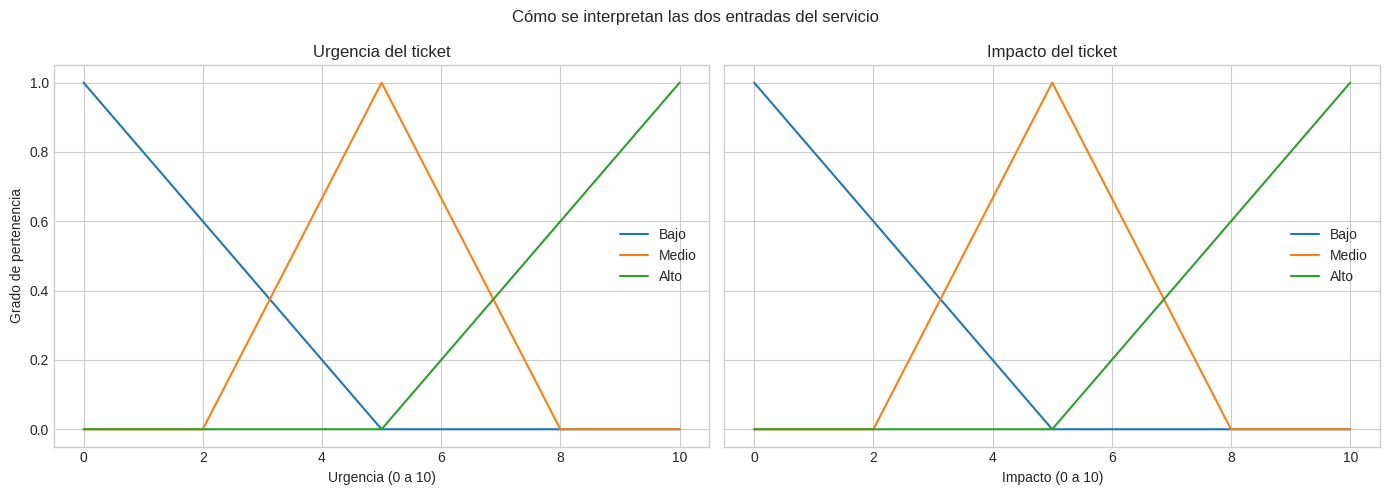

In [3]:
impacto_bajo = triangular(valores, 0, 0, 5)
impacto_medio = triangular(valores, 2, 5, 8)
impacto_alto = triangular(valores, 5, 10, 10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, conjuntos, titulo, xlabel in [
    (axes[0], (urgencia_baja, urgencia_media, urgencia_alta),
     "Urgencia del ticket", "Urgencia (0 a 10)"),
    (axes[1], (impacto_bajo, impacto_medio, impacto_alto),
     "Impacto del ticket", "Impacto (0 a 10)")
]:
    ax.plot(valores, conjuntos[0], label="Bajo")
    ax.plot(valores, conjuntos[1], label="Medio")
    ax.plot(valores, conjuntos[2], label="Alto")
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

axes[0].set_ylabel("Grado de pertenencia")
fig.suptitle("Cómo se interpretan las dos entradas del servicio")
plt.tight_layout()
plt.show()

**Interpretación sencilla:** las dos gráficas usan la misma idea, pero representan preguntas distintas. La primera pregunta ‘¿qué tan rápido necesita atención?’. La segunda pregunta ‘¿cuántas personas o procesos están afectados?’. En un ticket real, ambas respuestas pueden tener valores diferentes.

**Interpretación sencilla:** las categorías se pueden superponer. Por ejemplo, una urgencia de 5 podría ser parcialmente media y parcialmente alta. Esto evita cortes bruscos como ‘5 es media, pero 5.1 ya es alta’. La transición es gradual.

## 3. Medir la pertenencia de un ticket

Ahora probaremos un ticket con urgencia 7. La función `pertenencias` indica cuánto pertenece ese valor a cada categoría. El mismo procedimiento se aplicará al impacto.

In [4]:
def pertenencias(valor):
    return {
        "baja": float(triangular(valor, 0, 0, 5)),
        "media": float(triangular(valor, 2, 5, 8)),
        "alta": float(triangular(valor, 5, 10, 10))
    }

urgencia_ticket = 7
impacto_ticket = 8

print("Pertenencia de la urgencia 7:")
for categoria, grado in pertenencias(urgencia_ticket).items():
    print(f"{categoria}: {grado:.2f}")

print("Pertenencia del impacto 8:")
for categoria, grado in pertenencias(impacto_ticket).items():
    print(f"{categoria}: {grado:.2f}")

Pertenencia de la urgencia 7:
baja: 0.00
media: 0.33
alta: 0.40
Pertenencia del impacto 8:
baja: 0.00
media: 0.00
alta: 0.60


**Interpretación sencilla:** el ticket no se describe únicamente como ‘urgencia alta’ o ‘impacto alto’. Tiene grados de pertenencia. En este ejemplo, la urgencia 7 pertenece parcialmente a la categoría media y también a la alta; el impacto 8 se acerca más a la categoría alta.

## 4. Definir reglas de servicio

Las reglas convierten los conceptos difusos en una recomendación. Cada regla tiene un nivel de prioridad sugerido. Usaremos la operación `min` para representar la palabra `Y`: la fuerza de una regla es el menor grado entre sus condiciones.

Incluimos las nueve combinaciones posibles entre urgencia baja, media o alta e impacto bajo, medio o alto. Así evitamos que un ticket quede sin recomendación cuando presenta una combinación que no habíamos escrito.

In [5]:
reglas = [
    ("Baja urgencia y bajo impacto", "baja", "baja", 20),
    ("Baja urgencia e impacto medio", "baja", "media", 35),
    ("Urgencia media y bajo impacto", "media", "baja", 45),
    ("Baja urgencia y alto impacto", "baja", "alta", 60),
    ("Urgencia media e impacto medio", "media", "media", 60),
    ("Urgencia alta y bajo impacto", "alta", "baja", 70),
    ("Urgencia alta e impacto medio", "alta", "media", 80),
    ("Urgencia media e impacto alto", "media", "alta", 85),
    ("Urgencia alta e impacto alto", "alta", "alta", 100)
]

for nombre, urgencia, impacto, prioridad in reglas:
    print(f"SI urgencia {urgencia} Y impacto {impacto} → prioridad {prioridad}")

SI urgencia baja Y impacto baja → prioridad 20
SI urgencia baja Y impacto media → prioridad 35
SI urgencia media Y impacto baja → prioridad 45
SI urgencia baja Y impacto alta → prioridad 60
SI urgencia media Y impacto media → prioridad 60
SI urgencia alta Y impacto baja → prioridad 70
SI urgencia alta Y impacto media → prioridad 80
SI urgencia media Y impacto alta → prioridad 85
SI urgencia alta Y impacto alta → prioridad 100


**Interpretación sencilla:** una regla no dice que todos los tickets sean completamente bajos, medios o altos. Dice qué prioridad recomienda cuando el ticket se parece a esas categorías. Por ejemplo, un ticket muy urgente y de alto impacto recibe una prioridad cercana a 100.

## 5. Calcular la prioridad final

La función `priorizar_ticket` realiza cuatro pasos:

1. Calcula los grados de pertenencia de urgencia e impacto.
2. Calcula la fuerza de cada regla.
3. Combina las recomendaciones de las reglas.
4. Devuelve una prioridad entre 0 y 100.

Usaremos un promedio ponderado: una regla influye más cuando tiene mayor fuerza. Esta es una versión educativa y fácil de seguir del proceso de defuzzificación.

In [6]:
def priorizar_ticket(urgencia, impacto):
    pertenencia_urgencia = pertenencias(urgencia)
    pertenencia_impacto = pertenencias(impacto)
    activaciones = []

    for nombre, categoria_urgencia, categoria_impacto, prioridad in reglas:
        fuerza = min(
            pertenencia_urgencia[categoria_urgencia],
            pertenencia_impacto[categoria_impacto]
        )
        if fuerza > 0:
            activaciones.append({
                "regla": nombre,
                "fuerza": fuerza,
                "prioridad_sugerida": prioridad
            })

    numerador = sum(a["fuerza"] * a["prioridad_sugerida"] for a in activaciones)
    denominador = sum(a["fuerza"] for a in activaciones)
    prioridad_final = numerador / denominador if denominador else 0
    return prioridad_final, activaciones

prioridad, activaciones = priorizar_ticket(urgencia_ticket, impacto_ticket)
print(f"Prioridad final: {prioridad:.1f} de 100")
print("Reglas activadas:")
for activacion in activaciones:
    print(f"- {activacion['regla']}: fuerza {activacion['fuerza']:.2f}")

Prioridad final: 93.2 de 100
Reglas activadas:
- Urgencia media e impacto alto: fuerza 0.33
- Urgencia alta e impacto alto: fuerza 0.40


### ¿Cómo se obtiene el número final?

Cada regla produce dos cosas: una **fuerza** y una **prioridad sugerida**. La fuerza dice cuánto se parece el ticket a las condiciones de la regla. La prioridad sugerida dice qué valor recomienda esa regla.

La fórmula educativa utilizada es:

```text
prioridad final = suma(fuerza × prioridad sugerida) / suma(fuerzas)
```

Por ejemplo, una regla con fuerza 0.80 influye más que otra con fuerza 0.20. No estamos eligiendo una sola regla; estamos combinando las reglas que se activaron.

In [7]:
print("Detalle de las reglas que influyeron:")
print("Regla | Fuerza | Prioridad sugerida")
print("-" * 55)
for activacion in activaciones:
    print(
        f"{activacion['regla']} | "
        f"{activacion['fuerza']:.2f} | "
        f"{activacion['prioridad_sugerida']}"
    )

Detalle de las reglas que influyeron:
Regla | Fuerza | Prioridad sugerida
-------------------------------------------------------
Urgencia media e impacto alto | 0.33 | 85
Urgencia alta e impacto alto | 0.40 | 100


Esta tabla permite seguir el cálculo sin tratarlo como una caja negra. Si una persona pregunta por qué el ticket recibió cierta prioridad, podemos mostrar qué reglas participaron y cuánto influyó cada una.

### Convertir la prioridad numérica en una etiqueta humana

La cifra entre 0 y 100 es útil para ordenar tickets, pero las personas suelen necesitar una etiqueta sencilla. Por eso agregamos una clasificación orientativa. Los límites son decisiones del negocio y podrían cambiarse.

In [8]:
def clasificar_prioridad(prioridad):
    if prioridad < 35:
        return "baja"
    elif prioridad < 65:
        return "media"
    elif prioridad < 85:
        return "alta"
    else:
        return "crítica"

categoria = clasificar_prioridad(prioridad)
print(f"Prioridad numérica: {prioridad:.1f} de 100")
print(f"Categoría orientativa: {categoria}")

Prioridad numérica: 93.2 de 100
Categoría orientativa: crítica


**Interpretación sencilla:** la lógica difusa calcula primero una posición gradual. Después, si el negocio lo necesita, esa posición se convierte en una etiqueta. La etiqueta no reemplaza al número; solo facilita la comunicación. Un ticket con 64 y otro con 65 pueden quedar en categorías diferentes, aunque sus prioridades sean muy parecidas.

**Interpretación sencilla:** varias reglas pueden activarse al mismo tiempo. La prioridad final es una combinación gradual de sus recomendaciones. Esto evita que una sola frontera rígida decida todo el resultado. Para este ticket, el resultado debe interpretarse como una guía de priorización, no como una verdad absoluta.

## 6. Visualizar las reglas activadas

El siguiente gráfico muestra cuánto influyó cada regla en el ticket. Una barra más alta significa que esa regla tuvo mayor fuerza.

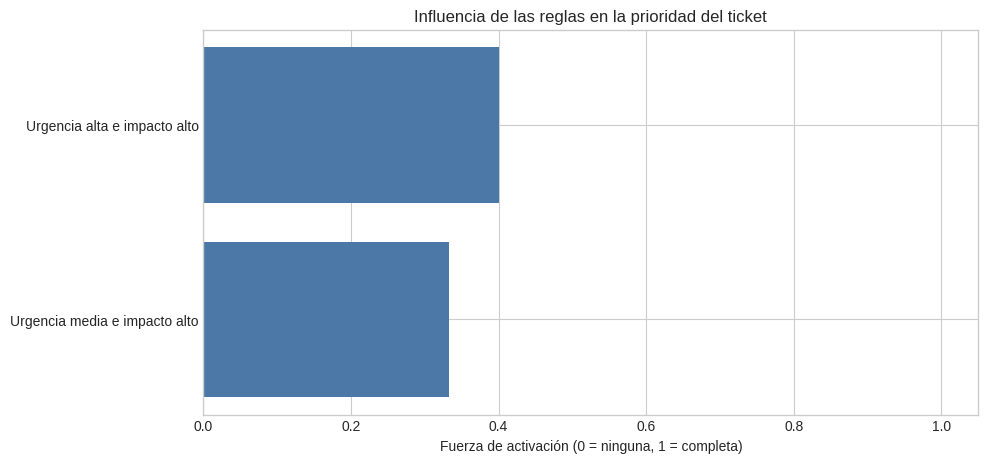

In [9]:
nombres = [a["regla"].split(" y ")[0] for a in activaciones]
fuerzas = [a["fuerza"] for a in activaciones]

plt.figure(figsize=(10, 5))
plt.barh(nombres, fuerzas, color="#4C78A8")
plt.xlim(0, 1.05)
plt.xlabel("Fuerza de activación (0 = ninguna, 1 = completa)")
plt.title("Influencia de las reglas en la prioridad del ticket")
plt.show()

**Interpretación sencilla:** las barras muestran que el sistema no tomó la decisión a partir de una sola regla. Las reglas que describen mejor el ticket tienen barras más grandes y pesan más en la prioridad final.

## 7. Comparar varios casos de servicio

Probamos cuatro tickets para observar cómo cambia la prioridad cuando cambian la urgencia y el impacto.

Consulta sencilla: urgencia=2, impacto=2, prioridad=20.0
Falla individual urgente: urgencia=8, impacto=3, prioridad=74.5
Falla general moderada: urgencia=4, impacto=8, prioridad=78.8
Caída crítica del servicio: urgencia=9, impacto=9, prioridad=100.0


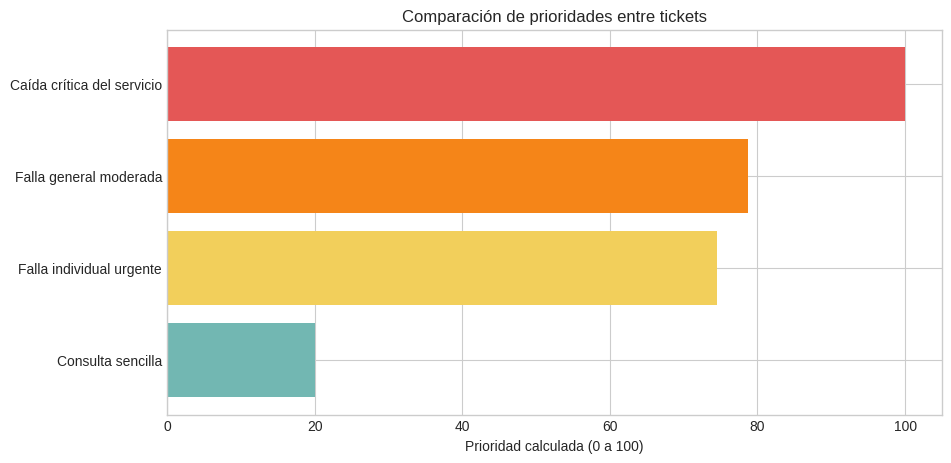

In [10]:
casos = {
    "Consulta sencilla": (2, 2),
    "Falla individual urgente": (8, 3),
    "Falla general moderada": (4, 8),
    "Caída crítica del servicio": (9, 9)
}

resultados = []
for nombre, (urgencia, impacto) in casos.items():
    prioridad, _ = priorizar_ticket(urgencia, impacto)
    resultados.append((nombre, urgencia, impacto, prioridad))

for nombre, urgencia, impacto, prioridad in resultados:
    print(f"{nombre}: urgencia={urgencia}, impacto={impacto}, prioridad={prioridad:.1f}")

nombres_casos = [r[0] for r in resultados]
prioridades = [r[3] for r in resultados]
plt.figure(figsize=(10, 5))
plt.barh(nombres_casos, prioridades, color=["#72B7B2", "#F2CF5B", "#F58518", "#E45756"])
plt.xlim(0, 105)
plt.xlabel("Prioridad calculada (0 a 100)")
plt.title("Comparación de prioridades entre tickets")
plt.show()

**Interpretación sencilla:** la consulta sencilla obtiene una prioridad baja. La caída crítica obtiene una prioridad mucho mayor porque combina urgencia e impacto altos. Los casos intermedios quedan entre ambos extremos; no hay un salto brusco de ‘no urgente’ a ‘crítico’.

## Lectura guiada de todo el ejercicio

### Bloque 1: preparar el entorno

Aquí solo cargamos las herramientas necesarias. `numpy` nos ayuda a trabajar con muchos números y `matplotlib` nos ayuda a dibujar. Estas bibliotecas no deciden la prioridad; solo permiten calcular y observar el proceso.

### Bloque 2: crear funciones de pertenencia

La función triangular dibuja una categoría. Cuando el valor está en el centro del triángulo, la pertenencia es alta. Cuando está lejos, la pertenencia baja. Esto representa una idea humana de manera numérica.

Por ejemplo, la palabra ‘urgencia alta’ no empieza exactamente en un número único. Puede comenzar a aparecer desde cierto nivel y crecer poco a poco. Por eso las categorías pueden superponerse.

### Bloque 3: medir un ticket

Este bloque toma los números del ticket y pregunta: ‘¿cuánto se parece a urgencia baja, media o alta?’. Hace lo mismo con el impacto. El resultado no es una etiqueta única; es un conjunto de grados.

### Bloque 4: escribir reglas de servicio

Las reglas representan el criterio del equipo de soporte. Por ejemplo, un problema poco urgente y de poco impacto puede esperar. Un problema muy urgente y que afecta a toda la empresa debe atenderse primero.

El número final de cada regla es una recomendación. No es una verdad descubierta por el sistema; es una decisión de diseño que el equipo debe revisar.

### Bloque 5: calcular la prioridad

La computadora revisa todas las reglas. Algunas tendrán fuerza cero y no participarán. Otras tendrán una fuerza parcial, como 0.30 o 0.70. Finalmente, combina las recomendaciones dando más peso a las reglas con mayor fuerza.

Por eso dos tickets parecidos pueden recibir prioridades parecidas, pero no necesariamente idénticas. Esta suavidad es una característica buscada de la lógica difusa.

### Bloque 6: observar la influencia de las reglas

Las barras muestran qué reglas influyeron en la decisión. Una barra grande significa que el ticket encaja mejor con las condiciones de esa regla. Esto ayuda a explicar la decisión a un supervisor.

### Bloque 7: comparar casos

Este bloque prueba que el modelo no está diseñado para un solo ticket. Cambiamos urgencia e impacto y observamos cómo cambia la prioridad. La comparación ayuda a detectar si las reglas producen resultados razonables.

## ¿Cómo se usaría en un servicio real?

Un sistema real podría recibir urgencia e impacto desde un formulario, un chatbot o un sistema de tickets. Después calcularía una prioridad y la utilizaría para ordenar la cola de atención.

Ejemplo de proceso:

1. El cliente registra un problema.
2. El sistema pregunta cuántas personas están afectadas.
3. El sistema estima la urgencia por el tiempo de espera o por el tipo de falla.
4. La lógica difusa calcula una prioridad.
5. El ticket se asigna a un agente o se escala a un supervisor.
6. La persona puede revisar qué reglas produjeron la prioridad.

## ¿Qué debe revisar una empresa antes de usarlo?

- Validar las reglas con personal experimentado.
- Revisar si los valores de prioridad son justos para todos los clientes.
- Comparar las prioridades calculadas con casos históricos.
- Permitir que un supervisor cambie manualmente una prioridad cuando exista una emergencia.
- Registrar las decisiones para poder auditarlas.
- Revisar periódicamente si el significado de ‘urgente’ o ‘alto impacto’ cambió.

## Actividades para el estudiante

1. Cambiar la urgencia del ticket a 3 y observar el resultado.
2. Mantener la urgencia en 7 y cambiar el impacto entre 2 y 9.
3. Agregar una regla para clientes VIP o servicios críticos.
4. Cambiar la prioridad sugerida de una regla y analizar el efecto.
5. Explicar con palabras qué reglas influyeron en un ticket.

La finalidad no es memorizar una fórmula. La finalidad es comprender que la lógica difusa permite convertir expresiones graduales del lenguaje humano en decisiones numéricas explicables.

## Conclusiones finales

- La lógica difusa es útil cuando las categorías no tienen límites completamente claros.
- Un ticket puede pertenecer parcialmente a varias categorías.
- Las reglas permiten incorporar experiencia humana en el proceso.
- La prioridad final es gradual y fácil de interpretar.
- Este enfoque puede apoyar la asignación de agentes, los acuerdos de nivel de servicio y la atención de incidentes.

### ¿Se aplicaría en la realidad?

Sí. Una empresa podría utilizarlo para ordenar tickets, priorizar llamadas, asignar supervisores o identificar clientes que necesitan atención inmediata. Antes de usarlo en producción habría que calibrar las funciones de pertenencia con datos históricos, validar las reglas con el equipo de servicio y revisar que no genere prioridades injustas.

### Limitación importante

Este notebook utiliza una versión educativa y simplificada. En un sistema profesional podrían emplearse métodos Mamdani o Sugeno, más variables, datos históricos y controles de calidad. El objetivo aquí es entender la idea: transformar valores numéricos en conceptos graduales, aplicar reglas y obtener una recomendación.

## Aplicaciones actuales de la lógica difusa

Actualmente se aplica en:

- Control de temperatura, agua, energía y procesos industriales.
- Robótica y sistemas autónomos.
- Dispositivos médicos y apoyo a decisiones.
- Sistemas explicables de IA.
- Clasificación y análisis de datos.
- Automatización de servicios y priorización de solicitudes.

Herramientas actuales mantienen ejemplos de control difuso para calefacción, temperatura, nivel de agua y controladores PID; también documentan aplicaciones en robótica, dispositivos médicos y sistemas explicables.

